<a href="https://colab.research.google.com/github/hair-loss/Digital-Image-Processing-Homeworks/blob/main/%EC%98%81%EC%83%81%EC%B2%98%EB%A6%AC_HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

In [2]:
from google.colab import drive
drive.mount('/content/dri')

Mounted at /content/dri


In [3]:
angio1 = cv2.imread("/content/dri/MyDrive/ImageProcessingAssignment/angio1.jpg")
angio2 = cv2.imread("/content/dri/MyDrive/ImageProcessingAssignment/angio2.jpg")

In [4]:
if angio1 is None or angio2 is None:
  print("Could not open or find the image")
  exit(0)

In [5]:
angio1.dtype #uint8
print(f"angio1's shape : {angio1.shape}")
print(f"angio2's shape : {angio2.shape}") #(624, 242, 3)으로 사이즈는 동일하다.
angio1 = angio1.astype(np.int16) #int8로 진행시 오버플로우 문제가 발생해서 astype으로 바꿈 이후에 int8로 재변환 예정
angio2 = angio2.astype(np.int16)
new_image = np.zeros(angio1.shape, angio1.dtype)
print(f"{new_image.dtype}, {new_image.shape}")


for y in range(new_image.shape[0]):
  for x in range(new_image.shape[1]):
    for c in range(new_image.shape[2]):
      new_image[y, x, c] = np.abs(angio1[y, x, c]-angio2[y, x, c]) #clip함수는 의미가 없다. 0~255 - 0~255를 뺀다고 하더라도 (-255~255) 범위에서 절댓값 씌우면 저절도 uint8 범위내에 들어가기 때문이다.
new_image = new_image.astype(np.uint8)

angio1's shape : (624, 242, 3)
angio2's shape : (624, 242, 3)
int16, (624, 242, 3)


origin #1


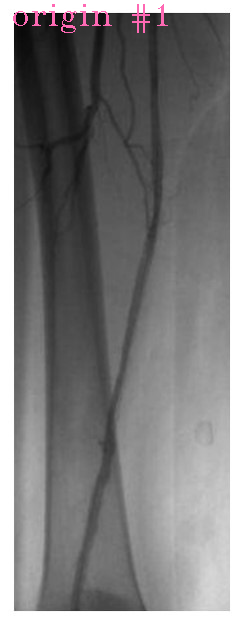

origin #2


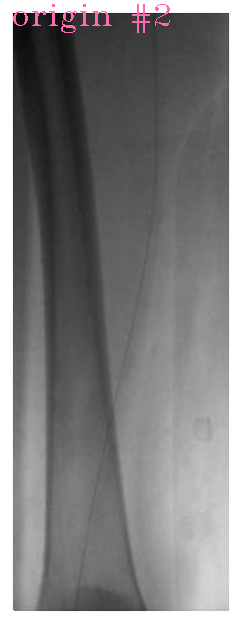

result


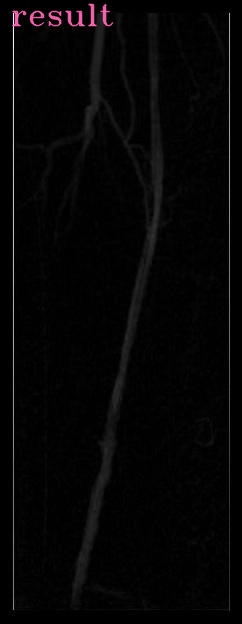

In [6]:
originName1 = "origin #1"
originName2 = "origin #2"
destName = "result"

custom_color = (180, 105, 255)

cv2.putText(angio1, originName1, (10, 25), cv2.FONT_HERSHEY_TRIPLEX, 1, custom_color, 1, cv2.LINE_AA)

cv2.putText(angio2, originName2, (10, 25), cv2.FONT_HERSHEY_TRIPLEX, 1, custom_color, 1, cv2.LINE_AA)

cv2.putText(new_image, destName, (10, 25), cv2.FONT_HERSHEY_TRIPLEX, 1, custom_color, 1, cv2.LINE_AA)

print(originName1)
cv2_imshow(angio1)
print(originName2)
cv2_imshow(angio2)
print(destName)
cv2_imshow(new_image)


In [7]:
angio2 = cv2.imread("/content/dri/MyDrive/ImageProcessingAssignment/angio2.jpg")
angio3 = cv2.imread("/content/dri/MyDrive/ImageProcessingAssignment/angio3.jpg")
print(f"{angio2.shape, angio3.shape}")
if angio2 is None or angio3 is None:
  print("Could not open or find the image")
  exit(0)

((624, 242, 3), (624, 242, 3))


In [8]:
best_ssd = float("inf")
best_dx, best_dy = 0, 0
search_range = 100

h, w, c = angio2.shape

block_h, block_w = 120, 80

cy, cx = h // 2, w // 2
print(cy,cx)
y1 = cy - block_h // 2
y2 = cy + block_h // 2
x1 = cx - block_w // 2
x2 = cx + block_w // 2

template = angio2[y1:y2, x1:x2, :]


for dy in range(-search_range, search_range + 1):
  for dx in range(-search_range, search_range + 1):
    yy1 = y1 + dy
    yy2 = y2 + dy
    xx1 = x1 + dx
    xx2 = x2 + dx

    if yy2 < 0 or yy2 > h or xx1 < 0 or xx2 > w:
      continue

    region = angio3[yy1:yy2, xx1:xx2, :]

    diff = template.astype(np.float32) - region.astype(np.float32)
    ssd = np.sum(diff**2)

    if ssd < best_ssd:
      best_ssd = ssd
      best_dx = dx
      best_dy = dy

print("Minimum SSD:", best_ssd)
print("Best shift(dx, dy)", best_dx, best_dy)

312 121
Minimum SSD: 37455.0
Best shift(dx, dy) -7 -13


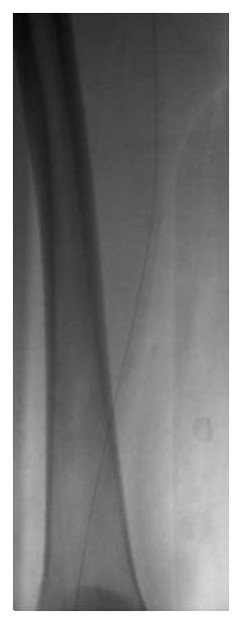

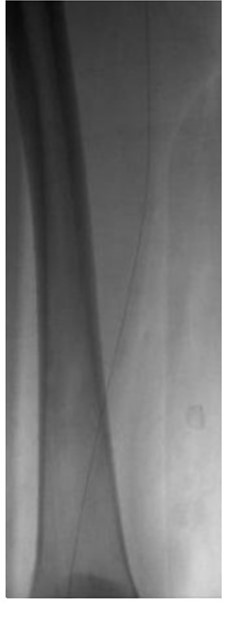

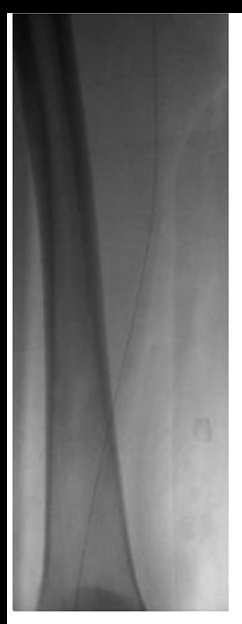

In [9]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

M = np.float32([[1, 0, -best_dx],
                [0, 1, -best_dy]])

shifted_img2 = cv2.warpAffine(angio3, M, (angio3.shape[1], angio3.shape[0]))

cv2_imshow(angio2)
cv2_imshow(angio3)
cv2_imshow(shifted_img2)